In [1]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import pandas as pd
import numpy as np
import io
import re
import os

/home/aegis/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# ==========================================
# 1. CONFIGURATION & CONSTANTS
# ==========================================
LUMI = 139  # fb^-1
# LUMI = LUMI = 139000  # fb^-1 converted to pb^-1 (Assuming 139 fb^-1 = 139,000 pb^-1)
N_GEN = 100000
OUTPUT_BASE = "/home/aegis/ether/Research_HEP/NRAD/Signal/replicate_atlas"

# Column names for the simulation files
COLS = [
    "pT_j1", "eta_j1", "phi_j1", "pT_j2", "eta_j2", "phi_j2", "m_jj", "sm_jj", 
    "tau21_j1", "tau21_j2", "tau32_j1", "tau32_j2", "met", "phi_met", 
    "min_dPhi", "ht", "pt_balance", "delta_phi_j1j2", "weight"
]

# Plotting Styles (Color, Linestyle)
STYLES = {
    '1000_6': ('#ff7f0e', '--'), '1000_8': ('#2ca02c', ':'),
    '2000_4': ('#d62728', ':'),  '2000_6': ('#1f77b4', '-.'),
    '3000_2': ('#9467bd', '-.'), '3000_4': ('#8c564b', '-.')
}

TARGET_MODES = ['1000_6', '1000_8', '2000_4', '2000_6', '3000_2', '3000_4']

# ==========================================
# UPDATED METADATA (Pythia Effective XS in fb)
# ==========================================
# Theory Uncertainty Calculation (approx from your logs):
# M=1000: Scale +52/-32%, PDF 4.5% -> ~52%
# M=2000: Scale +48/-30%, PDF 22%  -> Sqrt(0.48^2 + 0.22^2) ~ 53%
# M=3000: Scale +38/-25%, PDF 29%  -> Sqrt(0.38^2 + 0.29^2) ~ 48%

METADATA_LIST = [
    # Mass 1000 GeV (XS ~ 9550 fb)
    {"Mass": 1000, "Rinv": 2, "XS": 9551.0, "TheoryUnc": 0.52},
    {"Mass": 1000, "Rinv": 4, "XS": 9540.0, "TheoryUnc": 0.52},
    {"Mass": 1000, "Rinv": 6, "XS": 9552.0, "TheoryUnc": 0.52},
    {"Mass": 1000, "Rinv": 8, "XS": 9554.0, "TheoryUnc": 0.52},
    
    # Mass 2000 GeV (XS ~ 146 fb)
    {"Mass": 2000, "Rinv": 2, "XS": 146.3, "TheoryUnc": 0.53},
    {"Mass": 2000, "Rinv": 4, "XS": 146.8, "TheoryUnc": 0.53},
    {"Mass": 2000, "Rinv": 6, "XS": 146.1, "TheoryUnc": 0.53},
    {"Mass": 2000, "Rinv": 8, "XS": 145.3, "TheoryUnc": 0.53},
    
    # Mass 3000 GeV (XS ~ 14.2 fb)
    {"Mass": 3000, "Rinv": 2, "XS": 14.24, "TheoryUnc": 0.48},
    {"Mass": 3000, "Rinv": 4, "XS": 14.20, "TheoryUnc": 0.48},
    {"Mass": 3000, "Rinv": 6, "XS": 14.21, "TheoryUnc": 0.48},
    {"Mass": 3000, "Rinv": 8, "XS": 14.26, "TheoryUnc": 0.48},
]
DF_META = pd.DataFrame(METADATA_LIST)

# ==========================================
# 2. HELPER FUNCTIONS
# ==========================================
def get_hepdata_dict(filename):
    """Parses HEPData CSV into a dictionary of DataFrames."""
    if not os.path.exists(filename):
        print(f"Error: HEPData file {filename} not found.")
        return {}

    with open(filename, 'r') as f:
        content = f.read()
    
    blocks = content.strip().split('\n\n')
    data_dict = {}
    
    for block in blocks:
        lines = [l for l in block.split('\n') if not l.strip().startswith('#:')]
        if not lines: continue
        
        df = pd.read_csv(io.StringIO('\n'.join(lines)))
        df.columns = [c.strip() for c in df.columns]
        
        sig_col = next((c for c in df.columns if "Signal" in c), None)
        
        if sig_col:
            # Parse "Signal (1 TeV, R$_{inv}$ 0.6)" -> "1000_6"
            match = re.search(r'Signal \((\d+) TeV.* ([0-9\.]+)\)', sig_col)
            if match:
                mass_tev, r_val = match.groups()
                mass_gev = int(mass_tev) * 1000
                key_name = f"{mass_gev}_{r_val.replace('0.', '')[-1]}" 
                data_dict[key_name] = df
            else:
                data_dict[sig_col] = df # Fallback
                
    return data_dict

def get_cross_section(mode):
    """Retrieves XS from metadata based on mode string (e.g., '1000_6')."""
    try:
        parts = mode.split('_')
        mass = int(parts[0])
        rinv = int(parts[1])
        row = DF_META[(DF_META['Mass'] == mass) & (DF_META['Rinv'] == rinv)]
        return row.iloc[0]['XS']
    except (IndexError, ValueError):
        print(f"Warning: Metadata not found for {mode}")
        return 1.0


def get_metadata(mode):
    """Retrieves XS and Theory Uncertainty based on mode string."""
    try:
        parts = mode.split('_')
        mass = int(parts[0])
        rinv = int(parts[1])
        row = DF_META[(DF_META['Mass'] == mass) & (DF_META['Rinv'] == rinv)]
        return row.iloc[0]['XS'], row.iloc[0]['TheoryUnc']
    except (IndexError, ValueError):
        print(f"Warning: Metadata not found for {mode}")
        return 1.0, 0.0
    

# # ==========================================
# # 3. MAIN PLOTTING FUNCTION
# # ==========================================
# def compare_simulation_with_hepdata(
#     var_name,           # Column name in simulation df (e.g., 'ht')
#     hepdata_file,       # Path to HEPData csv
#     xlabel,             # Label for X-axis
#     norm_val,           # Normalization width (e.g., 100 for "Events / 100 GeV")
#     x_limits,           # Tuple (min, max)
#     y_limits=(0.01, 1e5)
# ):
#     """
#     Generates a comparison plot between local simulation and HEPData.
#     """
#     print(f"--- Processing {var_name} ---")
    
#     # 1. Load HEPData Reference
#     hep_data = get_hepdata_dict(hepdata_file)
#     if not hep_data: return

#     # 2. Extract Bin Edges from the first available HEPData frame
#     ref_key = list(hep_data.keys())[0]
#     ref_df = hep_data[ref_key]
#     # Assuming columns: [Center, Low, High, Value]
#     bin_edges = np.concatenate([ref_df.iloc[:, 1].values, [ref_df.iloc[:, 2].values[-1]]])
#     bin_widths = np.diff(bin_edges)

#     # 3. Setup Plot
#     fig, ax = plt.subplots(figsize=(10, 7))
    
#     for mode in TARGET_MODES:
#         # --- A. Load Simulation ---
#         path_final = os.path.join(OUTPUT_BASE, f"{mode}_events_markXI.txt")
#         if not os.path.exists(path_final):
#             continue
        
#         xs = get_cross_section(mode)
#         fix_val = 1.0
#         if mode.split('_')[0] == '1000':
#             fix_val = 1
#         if mode.split('_')[0] == '3000':
#             fix_val = 1

#         df_sim = pd.read_csv(path_final, sep='\s+', names=COLS, skiprows=1)
        
#         # Calculate Weights
#         norm_factor = (xs * LUMI) / N_GEN *fix_val

#         normalized_weights = np.ones(len(df_sim)) * norm_factor

#         # --- B. Process Simulation Data ---
#         counts, _ = np.histogram(df_sim[var_name], bins=bin_edges, weights=normalized_weights)
        
#         # Normalize: Count / (BinWidth / Normalization_Unit)
#         y_sim = counts / (bin_widths / norm_val)
        
#         # Plot Sim
#         c, ls = STYLES.get(mode, ('black', '-'))
#         # ax.step(bin_edges[:-1], y_sim, where='post', 
#         #         label=f"My Sim: {mode}", color=c, linestyle=ls, linewidth=2)
#         # Pass the full bin_edges array
#         # Append the last y-value to y_sim so shapes match (N+1, N+1)
#         ax.step(bin_edges, np.append(y_sim, y_sim[-1]), where='post', 
#                 label=f"My Sim: {mode}", color=c, linestyle=ls, linewidth=2)

#         # --- C. Plot HEPData Reference ---
#         if mode in hep_data:
#             ref_df = hep_data[mode]
#             y_col = [col for col in ref_df.columns if "Signal" in col][0]
#             ax.scatter(ref_df.iloc[:, 0], ref_df[y_col], color=c, marker='o', s=30, alpha=0.6)

#     # 4. Styling
#     ylabel = f"Events / {norm_val} GeV" if norm_val >= 1 else f"Events / {norm_val}"
    
#     ax.set_yscale('log')
#     ax.set_ylabel(ylabel, fontsize=12)
#     ax.set_xlabel(xlabel, fontsize=12)
#     ax.set_title(f"Comparison: Simulation vs HEPData ({var_name})", fontsize=14)
#     ax.set_xlim(*x_limits)
#     ax.set_ylim(*y_limits)
#     ax.legend(ncol=2, fontsize=10)
#     ax.grid(True, which="both", ls="--", alpha=0.3)
    
#     plt.tight_layout()
#     plt.show()


In [3]:
# def compare_simulation_with_hepdata(
#     var_name,           # Column name in simulation df (e.g., 'ht')
#     hepdata_file,       # Path to HEPData csv
#     xlabel,             # Label for X-axis
#     norm_val,           # Normalization width (e.g., 100 for "Events / 100 GeV")
#     x_limits,           # Tuple (min, max)
#     y_limits=(0.01, 1e5)
# ):
#     """
#     Generates a comparison plot between local simulation and HEPData
#     with a clean legend separating Simulation (Lines) and HEPData (Dots).
#     """
#     print(f"--- Processing {var_name} ---")
    
#     # 1. Load HEPData Reference
#     hep_data = get_hepdata_dict(hepdata_file)
#     if not hep_data: return

#     # 2. Extract Bin Edges from the first available HEPData frame
#     ref_key = list(hep_data.keys())[0]
#     ref_df = hep_data[ref_key]
#     bin_edges = np.concatenate([ref_df.iloc[:, 1].values, [ref_df.iloc[:, 2].values[-1]]])
#     bin_widths = np.diff(bin_edges)

#     # 3. Setup Plot
#     fig, ax = plt.subplots(figsize=(10, 7))
    
#     for mode in TARGET_MODES:
#         # --- A. Load Simulation ---
#         path_final = os.path.join(OUTPUT_BASE, f"{mode}_events_markXI.txt")
#         if not os.path.exists(path_final):
#             continue
        
#         xs = get_cross_section(mode)
#         fix_val = 1.0
#         if mode.split('_')[0] in ['1000', '3000']:
#             fix_val = 1

#         df_sim = pd.read_csv(path_final, sep='\s+', names=COLS, skiprows=1)
        
#         # Calculate Weights
#         norm_factor = (xs * LUMI) / N_GEN * fix_val
#         normalized_weights = np.ones(len(df_sim)) * norm_factor

#         # --- B. Process Simulation Data ---
#         counts, _ = np.histogram(df_sim[var_name], bins=bin_edges, weights=normalized_weights)
#         y_sim = counts / (bin_widths / norm_val)
        
#         # --- Style & Label Generation ---
#         c, ls = STYLES.get(mode, ('black', '-'))
        
#         # Create a readable label (e.g., "1 TeV, r=0.6")
#         parts = mode.split('_')
#         mass_tev = int(parts[0]) // 1000
#         rinv_val = parts[1]
#         label_txt = f"{mass_tev} TeV, $r_{{inv}}={rinv_val}.0$" if len(rinv_val)==1 else f"0.{rinv_val}"
#         # Adjust label string based on your specific format preference:
#         label_txt = f"{mass_tev} TeV, $r_{{inv}}$ 0.{rinv_val}"

#         # Plot Sim (Lines) - Apply Label Here
#         ax.step(bin_edges, np.append(y_sim, y_sim[-1]), where='post', 
#                 label=label_txt, color=c, linestyle=ls, linewidth=2)

#         # --- C. Plot HEPData Reference ---
#         if mode in hep_data:
#             ref_df = hep_data[mode]
#             y_col = [col for col in ref_df.columns if "Signal" in col][0]
#             # Plot Data (Dots) - NO Label here to avoid duplication
#             ax.scatter(ref_df.iloc[:, 0], ref_df[y_col], color=c, marker='o', s=30, alpha=0.6)

#     # 4. Styling & Custom Legend
#     ylabel = f"Events / {norm_val} GeV" if norm_val >= 1 else f"Events / {norm_val}"
    
#     ax.set_yscale('log')
#     ax.set_ylabel(ylabel, fontsize=12)
#     ax.set_xlabel(xlabel, fontsize=12)
#     ax.set_title(f"Comparison: Simulation vs HEPData ({var_name})", fontsize=14)
#     ax.set_xlim(*x_limits)
#     ax.set_ylim(*y_limits)
    
#     # --- Custom Legend Construction ---
#     # Get the handles for the lines (Physics Modes)
#     handles, labels = ax.get_legend_handles_labels()
    
#     # Create a generic "dummy" handle for HEPData
#     hepdata_handle = Line2D([0], [0], marker='o', color='black', linestyle='None',
#                             markerfacecolor='black', markersize=6, label='HEPData Ref.')
    
#     # Append the dummy handle to the list
#     handles.append(hepdata_handle)
    
#     # Display the legend
#     ax.legend(handles=handles, title="Sim (Lines) vs Ref (Dots)", ncol=2, fontsize=10)
    
#     ax.grid(True, which="both", ls="--", alpha=0.3)
    
#     plt.tight_layout()
#     plt.show()

In [4]:
# # ==========================================
# # 3. MAIN PLOTTING FUNCTION (UPDATED)
# # ==========================================
# def compare_simulation_with_hepdata(
#     var_name,           # Column name in simulation df (e.g., 'ht')
#     hepdata_file,       # Path to HEPData csv
#     xlabel,             # Label for X-axis
#     norm_val,           # Normalization width (e.g., 100 for "Events / 100 GeV")
#     x_limits,           # Tuple (min, max)
#     y_limits=(0.01, 1e5)
# ):
#     """
#     Generates a comparison plot with a main pad (log scale) and a ratio pad.
#     Includes statistical error bands for the simulation.
#     """
#     print(f"--- Processing {var_name} ---")

#     # 1. Load HEPData Reference
#     hep_data = get_hepdata_dict(hepdata_file)
#     if not hep_data: return

#     # 2. Extract Bin Edges from the first available HEPData frame
#     ref_key = list(hep_data.keys())[0]
#     ref_df = hep_data[ref_key]
    
#     # Assuming HEPData structure: [x_center, x_low, x_high, y, ...]
#     # We construct bin edges from the low edges + the last high edge
#     bin_edges = np.concatenate([ref_df.iloc[:, 1].values, [ref_df.iloc[:, 2].values[-1]]])
#     bin_widths = np.diff(bin_edges)
#     bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

#     # 3. Setup Plot with Ratio Panel (GridSpec)
#     fig = plt.figure(figsize=(10, 8))
#     gs = gridspec.GridSpec(2, 1, height_ratios=[3.5, 1], hspace=0.05)
    
#     ax_main = plt.subplot(gs[0])
#     ax_ratio = plt.subplot(gs[1], sharex=ax_main)

#     for mode in TARGET_MODES:
#         # --- A. Load Simulation ---
#         path_final = os.path.join(OUTPUT_BASE, f"{mode}_events_markXI.txt")
#         if not os.path.exists(path_final):
#             continue
        
#         xs = get_cross_section(mode)
        
#         # Manual fix factor if needed (from your original code)
#         fix_val = 1.0
#         if mode.split('_')[0] in ['1000', '3000']:
#             fix_val = 1.0

#         df_sim = pd.read_csv(path_final, sep='\s+', names=COLS, skiprows=1)
        
#         # Calculate Weights
#         # NOTE: Ensure LUMI and XS units match (pb vs fb)
#         norm_factor = (xs * LUMI) / N_GEN * fix_val
#         normalized_weights = np.ones(len(df_sim)) * norm_factor

#         # --- B. Process Simulation Data ---
        
#         # 1. Histogram of Counts (Weighted)
#         counts, _ = np.histogram(df_sim[var_name], bins=bin_edges, weights=normalized_weights)
        
#         # 2. Histogram of Variance (Sum of Weights Squared) for Error Calculation
#         sum_w2, _ = np.histogram(df_sim[var_name], bins=bin_edges, weights=normalized_weights**2)
        
#         # Calculate rates and errors normalized by bin width
#         # The factor 'norm_val' scales the Y-axis to "Events / X GeV"
#         scale_factor = (bin_widths / norm_val)
        
#         y_sim = counts / scale_factor
#         y_err = np.sqrt(sum_w2) / scale_factor # Statistical uncertainty

#         # --- C. Plotting Simulation (Main Pad) ---
#         c, ls = STYLES.get(mode, ('black', '-'))
        
#         # Parse Label
#         parts = mode.split('_')
#         mass_tev = int(parts[0]) // 1000
#         rinv_val = parts[1]
#         label_txt = f"{mass_tev} TeV, $r_{{inv}}$ 0.{rinv_val}"

#         # Plot Central Value (Step)
#         # We append the last value to extend the line to the edge of the last bin
#         ax_main.step(bin_edges, np.append(y_sim, y_sim[-1]), where='post', 
#                      label=label_txt, color=c, linestyle=ls, linewidth=2)
        
#         # Plot Statistical Uncertainty (Shaded Band)
#         # We assume uncorrelated errors for the band
#         # We duplicate the last error value to match the step plot behavior
#         y_sim_step = np.append(y_sim, y_sim[-1])
#         y_err_step = np.append(y_err, y_err[-1])
        
#         ax_main.fill_between(bin_edges, 
#                              y_sim_step - y_err_step,
#                              y_sim_step + y_err_step,
#                              step='post', color=c, alpha=0.2, edgecolor='none')

#         # --- D. Plotting HEPData (Main Pad) & Ratio ---
#         if mode in hep_data:
#             ref_df = hep_data[mode]
            
#             # Find the 'Signal' column (Y-values)
#             y_col = [col for col in ref_df.columns if "Signal" in col or "y" in col.lower()][0]
#             y_ref = ref_df[y_col].values
            
#             # Scatter Plot for Data
#             # Use bin centers for X coordinates
#             ax_main.scatter(bin_centers, y_ref, color=c, marker='o', s=30, alpha=0.8, zorder=5)

#             # --- E. Calculate & Plot Ratio (Data / Sim) ---
#             # Avoid division by zero
#             valid_bins = y_sim > 0
            
#             ratio = np.zeros_like(y_ref)
#             ratio[valid_bins] = y_ref[valid_bins] / y_sim[valid_bins]
            
#             # For the ratio plot, we just show the points
#             ax_ratio.scatter(bin_centers[valid_bins], ratio[valid_bins], color=c, marker='o', s=20)
            
#             # Optional: Add error bars to the ratio if HEPData has errors
#             # ratio_err = y_ref_err / y_sim

#     # 4. Styling Main Pad
#     ylabel = f"Events / {norm_val} GeV" if norm_val >= 1 else f"Events / {norm_val}"
    
#     ax_main.set_yscale('log')
#     ax_main.set_ylabel(ylabel, fontsize=12)
#     ax_main.set_title(f"Comparison: Simulation vs HEPData ({var_name})", fontsize=14)
#     ax_main.set_xlim(*x_limits)
#     ax_main.set_ylim(*y_limits)
#     ax_main.grid(True, which="major", ls="-", alpha=0.3)
    
#     # Hide x-labels on main pad to avoid overlap with ratio pad
#     plt.setp(ax_main.get_xticklabels(), visible=False)

#     # Custom Legend
#     handles, labels = ax_main.get_legend_handles_labels()
#     hepdata_handle = Line2D([0], [0], marker='o', color='black', linestyle='None',
#                             markerfacecolor='black', markersize=6, label='HEPData Ref.')
#     handles.append(hepdata_handle)
#     ax_main.legend(handles=handles, title="Sim (Band=Stat. Err) vs Ref (Dots)", ncol=2, fontsize=10)

#     # 5. Styling Ratio Pad
#     ax_ratio.set_ylabel("Data / Sim", fontsize=10)
#     ax_ratio.set_xlabel(xlabel, fontsize=12)
#     ax_ratio.set_xlim(*x_limits)
#     ax_ratio.set_ylim(0.0, 2.5) # Typical ratio range
#     ax_ratio.axhline(1.0, color='black', linestyle='--', linewidth=1)
#     ax_ratio.grid(True, which="both", ls="--", alpha=0.3)
    
#     plt.tight_layout()
#     plt.show()

In [9]:
# ==========================================
# 3. MAIN PLOTTING FUNCTION
# ==========================================
def compare_simulation_with_hepdata(
    var_name,           
    hepdata_file,       
    xlabel,             
    norm_val,           
    x_limits,           
    y_limits=(0.01, 1e5)
):
    print(f"--- Processing {var_name} ---")

    # 1. Load HEPData Reference
    hep_data = get_hepdata_dict(hepdata_file)
    if not hep_data: return

    # 2. Extract Bin Edges
    ref_key = list(hep_data.keys())[0]
    ref_df = hep_data[ref_key]
    bin_edges = np.concatenate([ref_df.iloc[:, 1].values, [ref_df.iloc[:, 2].values[-1]]])
    bin_widths = np.diff(bin_edges)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # 3. Setup Plot
    fig = plt.figure(figsize=(10, 8))
    gs = gridspec.GridSpec(2, 1, height_ratios=[3.5, 1], hspace=0.05)
    ax_main = plt.subplot(gs[0])
    ax_ratio = plt.subplot(gs[1], sharex=ax_main)

    for mode in TARGET_MODES:
        # --- A. Load Simulation ---
        # path_final = os.path.join(OUTPUT_BASE, f"{mode}_events_markXI.txt")
        path_final = os.path.join(OUTPUT_BASE, f"{mode}_events_markXI.txt")
        # path_final = os.path.join(OUTPUT_BASE, f"{mode}_events_mark_bare.txt")
        if not os.path.exists(path_final):
            continue
        
        # Get Pythia Effective XS and Theory Uncertainty
        xs_eff, theory_unc_frac = get_metadata(mode)
        
        fix_val = 1.0 # Remove specific fixes unless strictly necessary

        df_sim = pd.read_csv(path_final, sep='\s+', names=COLS, skiprows=1)
        
        # Calculate Weights
        # XS is in fb, LUMI is 139 fb^-1. Result is Number of Events.
        norm_factor = (xs_eff * LUMI) / N_GEN * fix_val
        normalized_weights = np.ones(len(df_sim)) * norm_factor

        # --- B. Histogramming ---
        
        # 1. Central Value
        counts, _ = np.histogram(df_sim[var_name], bins=bin_edges, weights=normalized_weights)
        
        # 2. Statistical Variance (Sum of Weights Squared)
        sum_w2, _ = np.histogram(df_sim[var_name], bins=bin_edges, weights=normalized_weights**2)
        
        # Scale to differential cross section unit (Events / norm_val GeV)
        scale_factor = (bin_widths / norm_val)
        
        y_sim = counts / scale_factor
        y_err_stat = np.sqrt(sum_w2) / scale_factor
        
        # 3. Add Theoretical Uncertainty
        # Theory error is percentage of the central value
        y_err_theory = y_sim * theory_unc_frac
        
        # Total Error (Quadrature sum of Stat + Theory)
        y_err_total = np.sqrt(y_err_stat**2 + y_err_theory**2)

        # --- C. Plotting Main Pad ---
        c, ls = STYLES.get(mode, ('black', '-'))
        
        parts = mode.split('_')
        mass_tev = int(parts[0]) // 1000
        rinv_val = parts[1]
        label_txt = f"{mass_tev} TeV, $r_{{inv}}$ 0.{rinv_val}"

        # Main Line
        ax_main.step(bin_edges, np.append(y_sim, y_sim[-1]), where='post', 
                     label=label_txt, color=c, linestyle=ls, linewidth=2)
        
        # Shaded Band (Total Uncertainty)
        y_sim_step = np.append(y_sim, y_sim[-1])
        y_err_step = np.append(y_err_total, y_err_total[-1])
        
        ax_main.fill_between(bin_edges, 
                             y_sim_step - y_err_step,
                             y_sim_step + y_err_step,
                             step='post', color=c, alpha=0.15, edgecolor='none')

        # --- D. Plotting Ratio Pad ---
        if mode in hep_data:
            ref_df = hep_data[mode]
            y_col = [col for col in ref_df.columns if "Signal" in col][0]
            y_ref = ref_df[y_col].values
            
            # Plot Ref Points on Main Pad
            ax_main.scatter(bin_centers, y_ref, color=c, marker='o', s=25, alpha=0.7)

            # Calculate Ratio
            valid_bins = y_sim > 0
            ratio = np.zeros_like(y_ref)
            ratio[valid_bins] = y_ref[valid_bins] / y_sim[valid_bins]
            
            # Ratio Points
            ax_ratio.scatter(bin_centers[valid_bins], ratio[valid_bins], color=c, marker='o', s=15)
            
            # Ratio Uncertainty Band (Centered at 1.0)
            # This shows the Simulation Uncertainty relative to itself
            # If the points fall inside this band, Data agrees with Sim within Sim errors
            rel_err = np.zeros_like(y_sim)
            rel_err[valid_bins] = y_err_total[valid_bins] / y_sim[valid_bins]
            
            # Use step plot for the ratio band to match bins
            rel_err_step = np.append(rel_err, rel_err[-1])
            ax_ratio.fill_between(bin_edges, 
                                  1.0 - rel_err_step, 
                                  1.0 + rel_err_step,
                                  step='post', color=c, alpha=0.15, edgecolor='none')

    # 4. Styling
    ylabel = f"Events / {norm_val} GeV" if norm_val >= 1 else f"Events / {norm_val}"
    
    ax_main.set_yscale('log')
    ax_main.set_ylabel(ylabel, fontsize=12)
    # ax_main.set_title(f"Comparison: Simulation vs HEPData ({var_name})", fontsize=14)
    ax_main.set_xlim(*x_limits)
    ax_main.set_ylim(*y_limits)
    plt.setp(ax_main.get_xticklabels(), visible=False)
    
    # Legend
    handles, labels = ax_main.get_legend_handles_labels()
    dummy_dot = Line2D([0], [0], marker='o', color='black', linestyle='None', label='HEPData')
    handles.append(dummy_dot)
    ax_main.legend(handles=handles, ncol=2, fontsize=17, loc='upper right')
    
    # Ratio Styling
    ax_ratio.set_ylabel("HepData / Sim", fontsize=10)
    ax_ratio.set_xlabel(xlabel, fontsize=12)
    ax_ratio.set_xlim(*x_limits)
    ax_ratio.set_ylim(0.0, 2.5)
    ax_ratio.axhline(1.0, color='black', linestyle='--', linewidth=1)
    ax_ratio.grid(True, which="both", ls="--", alpha=0.3)
    ax_main.grid(True, which="major", ls="-", alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"plots/comparison_{var_name}.pdf")
    plt.show()

--- Processing ht ---


/tmp/ipykernel_70225/2092189523.py:148: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


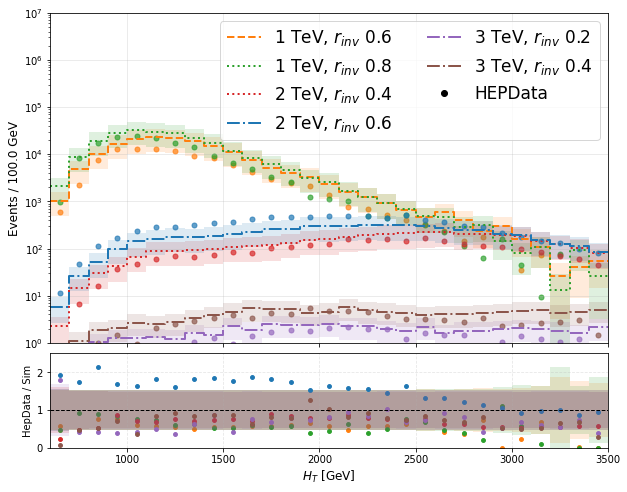

--- Processing met ---


/tmp/ipykernel_70225/2092189523.py:148: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


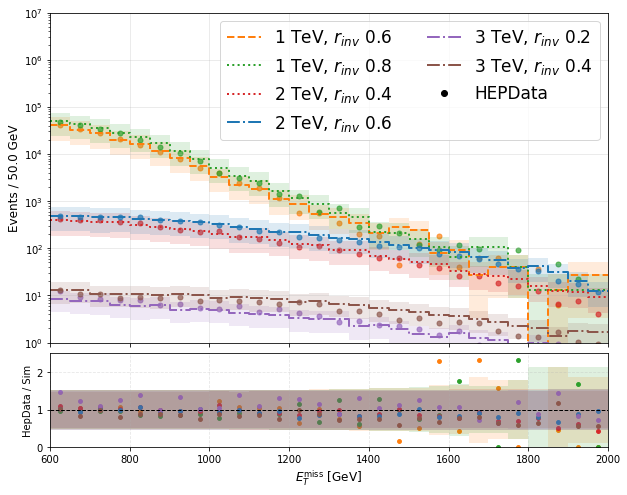

--- Processing delta_phi_j1j2 ---


/tmp/ipykernel_70225/2092189523.py:148: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


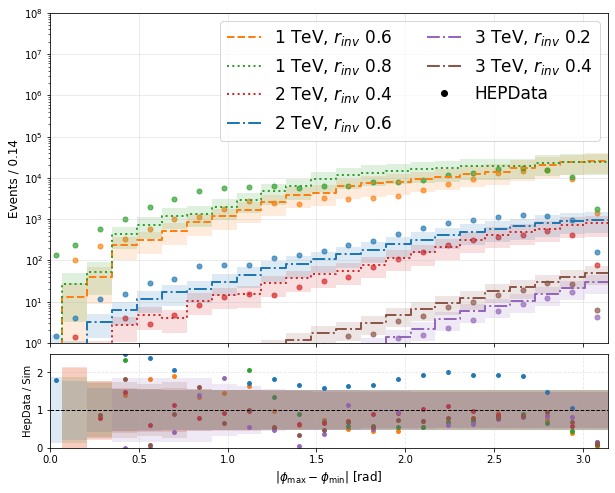

--- Processing pt_balance ---


/tmp/ipykernel_70225/2092189523.py:148: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


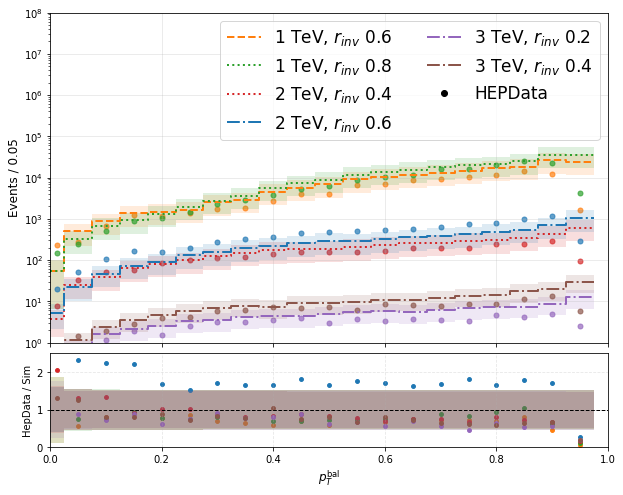

In [10]:
# 1. Plot HT
compare_simulation_with_hepdata(
    var_name='ht',
    hepdata_file="HEPData-HT.csv",
    xlabel=r"$H_T$ [GeV]",
    norm_val=100.0,
    x_limits=(600, 3500),
    y_limits=(1, 1e7)
)

# 2. Plot MET
compare_simulation_with_hepdata(
    var_name='met',
    hepdata_file="HEPData-MET.csv",
    xlabel=r"$E^{\text{miss}}_T$ [GeV]",
    norm_val=50.0,
    x_limits=(600, 2000),
    y_limits=(1, 1e7)
)

# 3. Plot Delta Phi
compare_simulation_with_hepdata(
    var_name='delta_phi_j1j2',
    hepdata_file="HEPData-phi.csv",
    xlabel=r"$|\phi_{\text{max}} - \phi_{\text{min}}|$ [rad]",
    norm_val=0.14,  # Roughly pi/22 or specific bin width reference
    x_limits=(0, np.pi),
    y_limits=(1, 1e8)
)

# 4. Plot pT Balance
compare_simulation_with_hepdata(
    var_name='pt_balance',
    hepdata_file="HEPData-pT.csv",
    xlabel=r"$p^{\text{bal}}_T$",
    norm_val=0.05,
    x_limits=(0, 1),
    y_limits=(1, 1e8)
)